In [1]:
import os
import sys
import json
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configurare pentru a putea importa din folderele parinte
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

# Importuri din fisierele tale .py
from models.nerf_mlp import NeRF
from src.data_loader import load_nerf_data

%matplotlib inline
print("Mediul a fost configurat cu succes!")

Mediul a fost configurat cu succes!


Incarcare date pentru split-ul: train...
Dataset: LEGO
Imagini incarcate: (100, 800, 800, 4) (N, H, W, RGBA)
Distanța focală calculată: 1111.11


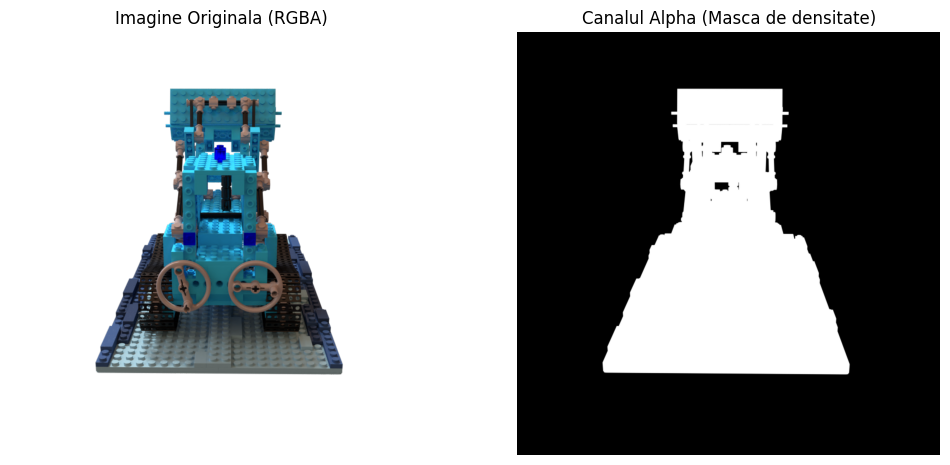

In [2]:
# Calea catre dataset-ul LEGO
base_path = os.path.join("..", "data", "lego")

# Utilizam functia din src/data_loader.py
images, poses, [H, W, focal] = load_nerf_data(base_path, split='train')

print(f"Dataset: LEGO")
print(f"Imagini incarcate: {images.shape} (N, H, W, RGBA)")
print(f"Distanța focală calculată: {focal:.2f}")

# Vizualizare imagine si canal Alpha (Transparenta)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(images[0])
plt.title("Imagine Originala (RGBA)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(images[0][:, :, 3], cmap='gray')
plt.title("Canalul Alpha (Masca de densitate)")
plt.axis('off')
plt.show()

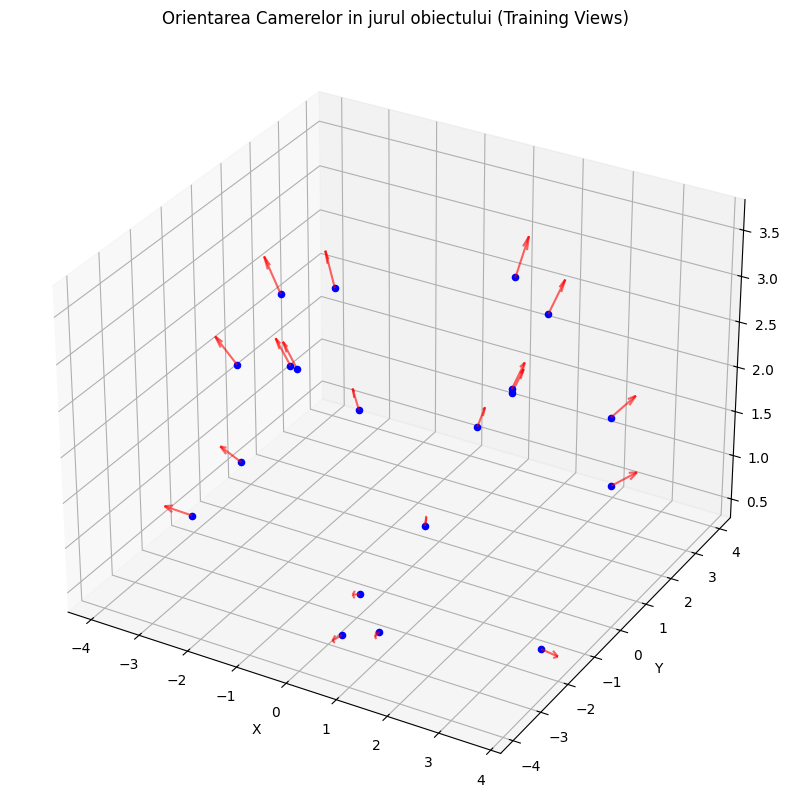

In [3]:
def plot_cameras(poses, scale=0.5):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    for i in range(0, len(poses), 5): # Afisam una din 5 pentru claritate
        # Originea camerei
        center = poses[i][:3, 3]
        ax.scatter(center[0], center[1], center[2], c='blue', s=20)
        
        # Orientarea camerei (axa Z)
        z_dir = poses[i][:3, 2]
        ax.quiver(center[0], center[1], center[2], 
                  z_dir[0], z_dir[1], z_dir[2], 
                  length=scale, color='red', alpha=0.6)

    ax.set_title("Orientarea Camerelor in jurul obiectului (Training Views)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

plot_cameras(poses)

In [4]:
# Parametrii pentru Positional Encoding (L_pts=10, L_views=4)
input_ch = 3 + 3 * 2 * 10       # 63
input_ch_views = 3 + 3 * 2 * 4  # 27

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeRF(input_ch=input_ch, input_ch_views=input_ch_views).to(device)

# Cream un tensor de test (1 raza, 64 puncte, input_ch + input_ch_views)
test_input = torch.randn(1, 64, input_ch + input_ch_views).to(device)

# Verificam daca modelul proceseaza datele
with torch.no_grad():
    output = model(test_input)

print(f"Test Model NeRF: SUCCES")
print(f"Forma output (RGB + Sigma): {output.shape}") # Asteptat: [1, 64, 4]

Test Model NeRF: SUCCES
Forma output (RGB + Sigma): torch.Size([1, 64, 4])


## 🏁 Concluzii Etapa 1
1. **Infrastructura**: Repository-ul este organizat modular (src, models, data).
2. **Validare**: Geometria camerelor și încărcarea datelor sunt confirmate experimental.
3. **Model**: Arhitectura MLP este funcțională și integrată cu pipeline-ul de date.

**Plan pentru Etapa 2 (S6-S9):**
* Implementarea loop-ului de antrenare și a funcției de randare volumetrică.
* Optimizarea consumului de memorie și obținerea primelor reconstrucții 3D.